In [41]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set up data path - point to the RUT dataset
data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT"

# Create destination folder for merged files
dest_path = f"{data_path}/merged_output"
os.makedirs(dest_path, exist_ok=True)

print(f"Data path: {data_path}")
print(f"Output path: {dest_path}")
print(f"\nAvailable ROIs:")
!ls -d {data_path}/*ROI/ | xargs -I {{}} basename {{}}

Data path: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT
Output path: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output

Available ROIs:
013_ROI
014_ROI
015_ROI
017_ROI
018_ROI
019_ROI
020_ROI
021_ROI
022_ROI
023_ROI
024_ROI
025_ROI
026_ROI


# Tutorial 1: Merge Multi-ROI Chromatin Trace Data

Complete workflow for merging chromatin tracing data from multiple regions of interest (ROIs).

## Step 1: Copy Localization Files from All ROIs

In [42]:
# Copy raw localization files (.dat format) from all ROIs
!localization_cp_files --files {data_path}/*/localize_3d/data/*barcode.dat --dest {dest_path}/raw_localization

print(f"✓ Localization files copied")
!ls {dest_path}/raw_localization/ | wc -l
print("localizations files")

Created destination folder: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization
Processing 13 files
Copied: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/013_ROI/localize_3d/data/localizations_3D_barcode.dat -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_013_ROI.dat
Copied: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/014_ROI/localize_3d/data/localizations_3D_barcode.dat -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_014_ROI.dat
Copied: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/015_ROI/localize_3d/data/localizations_3D_barcode.dat -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_015_ROI.dat
Copied: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/017_ROI/localize_3d/data/localizations_3D_barcode.dat -> /home/xdevos/Repositories

## Step 2: Merge Localization Files

In [43]:
# Convert and merge all localization .dat files into a single ECSV table
!ls {dest_path}/raw_localization/*.dat | localization_merge -O {dest_path}/dest -o merged_localizations.ecsv

print(f"✓ Localizations merged")
!ls -lh {dest_path}/dest/merged_localizations.ecsv

Input parameters
---------------
outputFolder-->/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest
output_file-->merged_localizations.ecsv
loc_files-->['/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_013_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_014_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_015_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_017_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_018_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_localization/localizations_3D_barcode_019_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_loc

## Step 3: Copy ONLY the Trace Files (not Matrix files)

In [44]:
# Create directory for raw traces
!mkdir -p {dest_path}/raw_traces

# Copy ONLY the actual trace files (exclude _Matrix_uniqueBarcodes.ecsv files)
# Use find to exclude Matrix files
!find {data_path}/*/tracing/data -name "*mask-mask0_ROI*.ecsv" ! -name "*Matrix*" -exec cp {{}} {dest_path}/raw_traces/ \;

print(f"✓ Trace files copied (Matrix files excluded)")
!ls {dest_path}/raw_traces/ | wc -l
print("trace files")

✓ Trace files copied (Matrix files excluded)
13
trace files


## Step 4: Merge Trace Files

In [45]:
# Merge all trace files into a single table
!ls {dest_path}/raw_traces/*.ecsv | trace_merge -F {dest_path}/dest -N merged_traces.ecsv

print(f"✓ Traces merged")
!ls -lh {dest_path}/dest/merged_traces.ecsv

Number of trace files to merge: 13
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-13.ecsv
 $ appended trace file with 13676 traces
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-14.ecsv
 $ appended trace file with 13598 traces
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-15.ecsv
 $ appended trace file with 6175 traces
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-17.ecsv
 $ appended trace file with 13180 traces
$ Importing table from pyHiM format
Successfully l

## Step 5: Compute Basic Statistics

In [46]:
# Generate basic statistics (prints to stdout)
!trace_stats --input {dest_path}/dest/merged_traces.ecsv

print("\n✓ Statistics computed")

$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
Statistics for /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv:
- Number of unique ROIs: 13
- Number of unique chromatin traces: 26591
- Number of unique barcodes: 25

✓ Statistics computed


## Step 6: Generate Quality Control Metrics

In [47]:
# Run comprehensive trace analysis
# -F specifies the output folder for plots
!trace_analyzer --input {dest_path}/dest/merged_traces.ecsv -F {dest_path}/dest

print("✓ Analysis complete - plots generated")


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
$ Number of spots in trace file: 117211
$ Calculating overall barcode detection across 26591 traces...
$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces_barcode_detection.png
$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.002
$ Calculating barcode stats...
100%|███████████████████████████████████| 26591/26591 [00:03<00:00, 7368.89it/s]
$ Exporting relati


▶ merged_traces_trace_statistics.png:


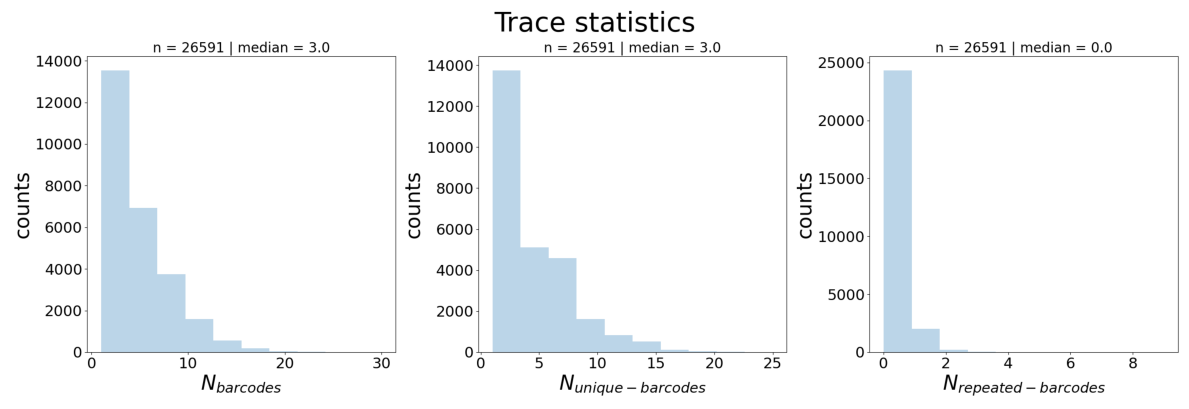


▶ merged_traces_barcode_detection.png:


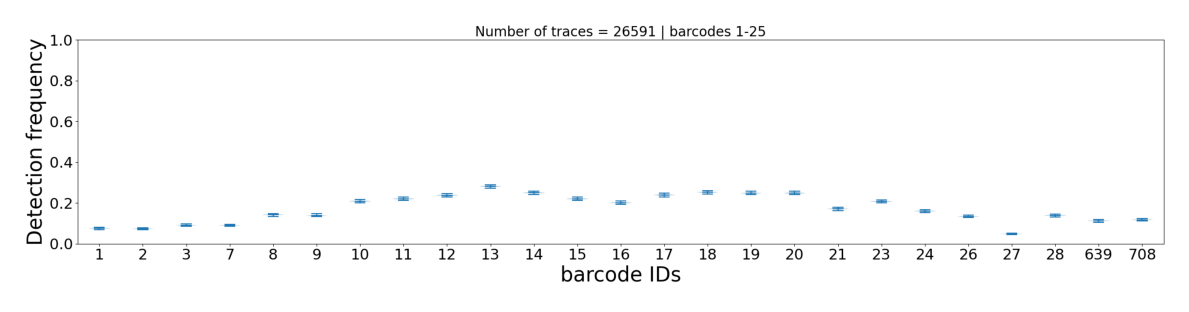


▶ merged_traces_relative_barcode_frequencies.png:


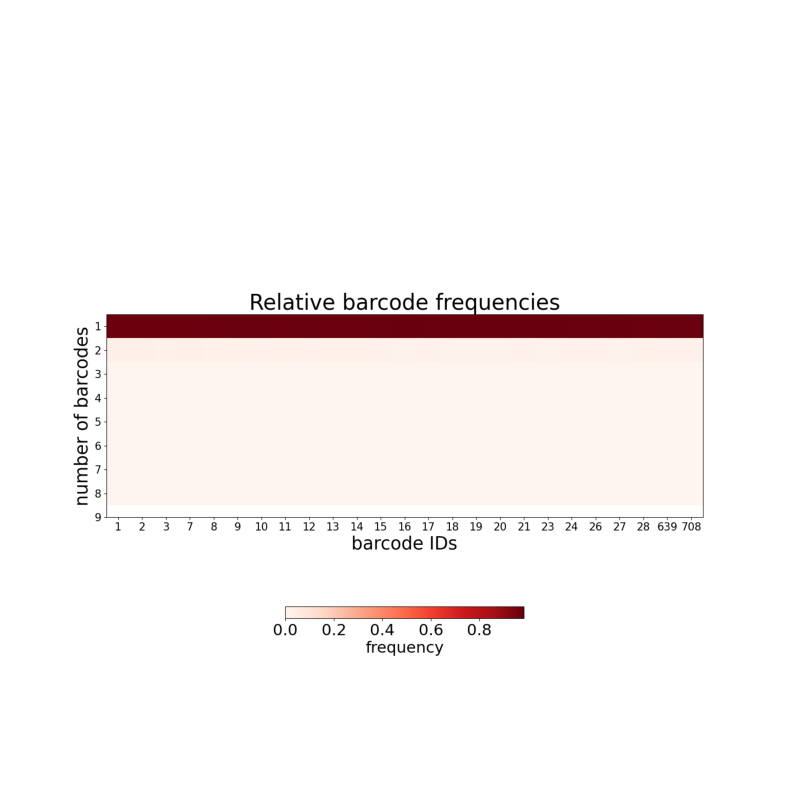


▶ merged_traces_first_neighbor_distances.png:


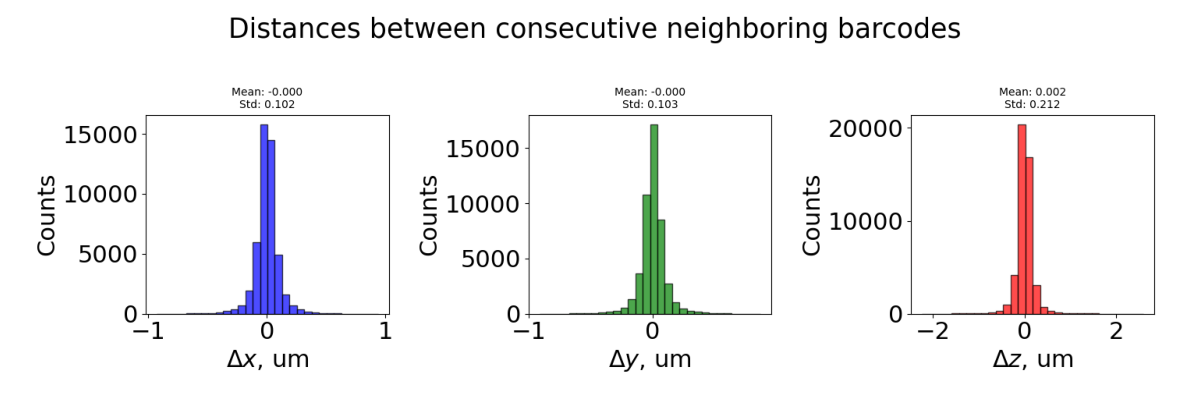

In [49]:
# Display generated plots
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plot_files = [
    "merged_traces_trace_statistics.png",
    "merged_traces_barcode_detection.png",
    "merged_traces_relative_barcode_frequencies.png",
    "merged_traces_first_neighbor_distances.png"
]

dest_folder = f"{dest_path}/dest"
for plot_file in plot_files:
    plot_path = os.path.join(dest_folder, plot_file)
    if os.path.exists(plot_path):
        print(f"\n▶ {plot_file}:")
        img = mpimg.imread(plot_path)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"✗ {plot_file} not found")

## Step 7: Compute Pearson Correlations Between ROIs

In [52]:
# Compute Pearson correlations between individual ROI trace files
# This shows how similar each ROI's chromatin structure is to the others
# -O specifies the output folder for plots
!ls {dest_path}/raw_traces/*.ecsv | trace_pearsons --pipe -O {dest_path}/dest

print("\n✓ Pearson correlations between ROIs computed")

Analyzing 13 trace files...
Processing Trace_3D_barcode_mask-mask0_ROI-13.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-13.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-14.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-14.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-15.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-15.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-17.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-17.ecsv
Processing Trace


▶ Pearson Correlation Matrix (ROI comparison):


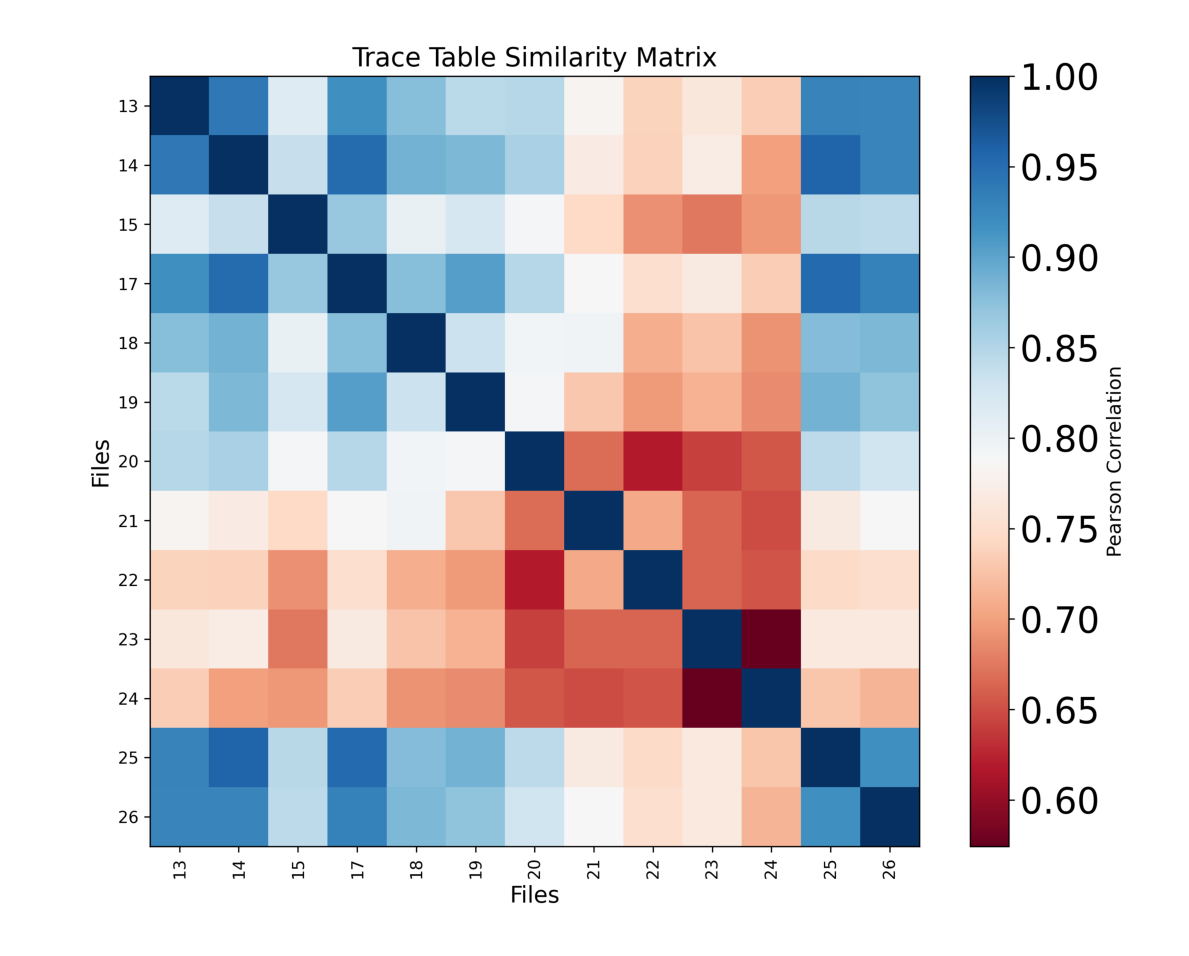

In [53]:
# Display correlation matrix plot (comparing ROIs)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

corr_plot = os.path.join(f"{dest_path}/dest", "trace_correlation_matrix.png")
if os.path.exists(corr_plot):
    print("\n▶ Pearson Correlation Matrix (ROI comparison):")
    img = mpimg.imread(corr_plot)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("✗ Correlation plot not found")

## Summary

Complete merged dataset ready:

- ✓ merged_localizations.ecsv (ROIs merged)
- ✓ merged_traces.ecsv (ROIs merged)
- ✓ Quality metrics & statistics plots (from merged data)
- ✓ Pearson correlation matrix (comparing individual ROIs)

**Output location:** `merged_output/dest/`

**Insights:**
- The correlation matrix shows how similar chromatin structure is across different ROIs
- High correlation between ROIs suggests consistent chromatin organization
- Low correlation may indicate regional variation or experimental variation

**Next:** Tutorial 2 - Quality Control & Filtering